In [1]:
import pandas as pd
df = pd.read_csv("telco_churn.csv", index_col = 'customerID')

In [2]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 7590-VHVEG to 3186-AJIEK
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 

In [6]:
df.shape

(7043, 20)

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

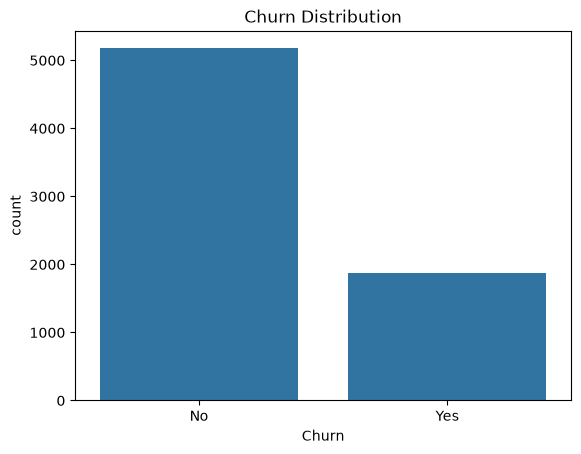

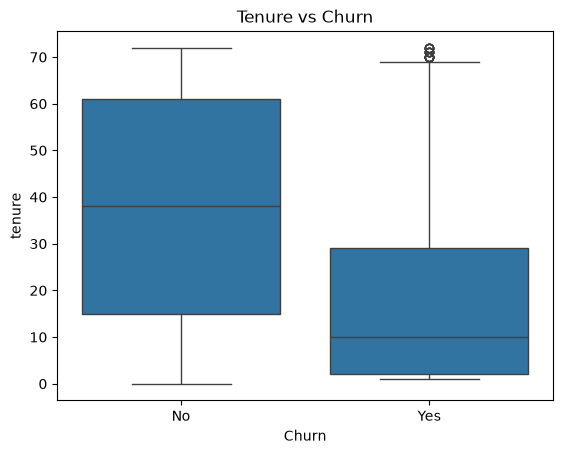

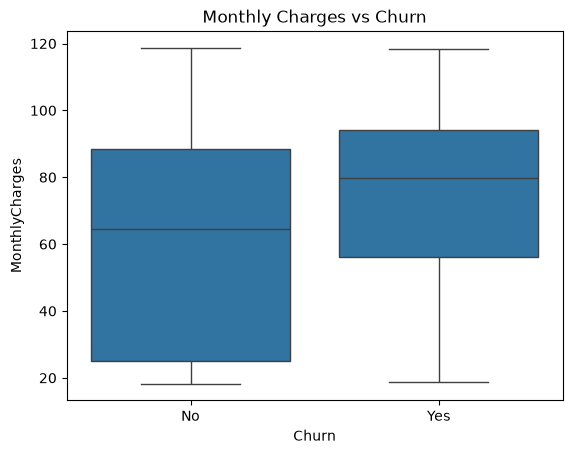

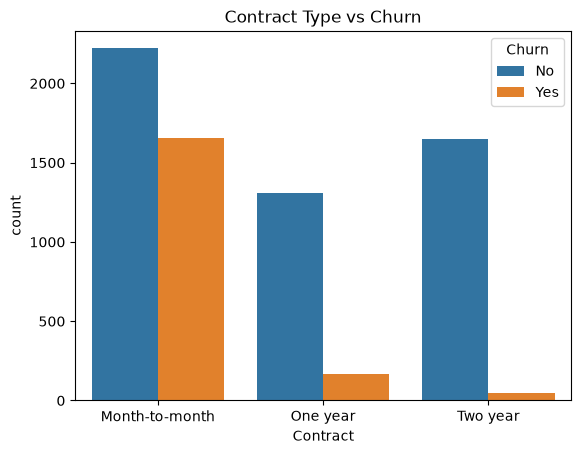

In [10]:
os.makedirs('outputs/charts', exist_ok=True)

# Chart 1
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.savefig('outputs/charts/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.savefig('outputs/charts/02_tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.savefig('outputs/charts/03_monthlycharges_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 4
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.savefig('outputs/charts/04_contract_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print(df['TotalCharges'].dtype)

float64


In [4]:
df['Churn'] = df['Churn'].astype(object)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [5]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
5575-GNVDE,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
3668-QPYBK,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
7795-CFOCW,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
9237-HQITU,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
2234-XADUH,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
4801-JZAZL,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [57]:
df.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [59]:
df.dtypes.value_counts()

bool       26
int64       3
float64     2
Name: count, dtype: int64

In [60]:
[col for col in df.columns if 'gender' in col or 'Contract' in col or 'PaymentMethod' in col]

['gender_Male',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [7]:
df.to_csv('telco_churn_train.csv', index=True)

In [9]:
df = pd.read_csv("telco_churn_train.csv", index_col = 'customerID')
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
5575-GNVDE,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
3668-QPYBK,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
7795-CFOCW,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
9237-HQITU,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
2234-XADUH,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
4801-JZAZL,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [11]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Churn'])
y = df['Churn']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

[            SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
 customerID                                                                     
 1830-GGFNM              0      65           94.55       6078.75         True   
 4501-VCPFK              0      26           35.75       1022.50         True   
 8871-JLMHM              0      68           90.20       6297.65        False   
 0225-ZORZP              0       3           84.30        235.05         True   
 1530-ZTDOZ              0      49           40.65       2070.75        False   
 ...                   ...     ...             ...           ...          ...   
 5397-TUPSH              1      65           70.95       4555.20         True   
 8020-BWHYL              1      15           75.30       1147.45        False   
 8670-MEFCP              0      36           92.90       3379.25        False   
 7919-ZODZZ              0      10           65.90        660.05        False   
 5240-IJOQT              1  

In [15]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.735608
1    0.264392
Name: proportion, dtype: float64

In [17]:
print("Train:")
print(y_train.value_counts(normalize=True))

Train:
Churn
0    0.733867
1    0.266133
Name: proportion, dtype: float64


In [18]:
print("Test:")
print(y_test.value_counts(normalize=True))

Test:
Churn
0    0.735608
1    0.264392
Name: proportion, dtype: float64
